In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.feature_selection import SelectPercentile, f_regression, mutual_info_regression
from sklearn.inspection import permutation_importance

import statsmodels.api as sm
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan

from sklearn.feature_selection import SelectKBest


In [2]:
plt.rcParams["figure.figsize"] = (14, 5)
sns.set_style("whitegrid")
pd.set_option("display.max_columns", 150)
pd.set_option("display.width", 200)

# 1. EDA

In [3]:
# Загрузка
df_sensors = pd.read_csv("data_train.csv", parse_dates=["datetime"])
df_lab = pd.read_csv("target_train.csv", parse_dates=["Дата"]).rename(columns={"Дата": "datetime"})
df_sensors_test = pd.read_csv("data_test_small.csv", parse_dates=["datetime"])
df_lab_test = pd.read_csv("target_test_small.csv", parse_dates=["Дата"]).rename(columns={"Дата": "datetime"})

print("="*60)
print("РАЗМЕРЫ ДАННЫХ")
print("="*60)
print(f"Обучающая выборка датчиков: {df_sensors.shape}")
print(f"Обучающая выборка лабораторных данных: {df_lab.shape}")
print(f"Тестовая выборка датчиков: {df_sensors_test.shape}")
print(f"Тестовая выборка лабораторных данных: {df_lab_test.shape}")

# Список всех датчиков
sensor_columns = [c for c in df_sensors.columns if c.startswith("telemetry_")]
print(f"\nДатчики: {sensor_columns[:5]}... всего {len(sensor_columns)}")


РАЗМЕРЫ ДАННЫХ
Обучающая выборка датчиков: (319546, 17)
Обучающая выборка лабораторных данных: (1773, 2)
Тестовая выборка датчиков: (39943, 17)
Тестовая выборка лабораторных данных: (318, 2)

Датчики: ['telemetry_0', 'telemetry_1', 'telemetry_2', 'telemetry_3', 'telemetry_4']... всего 16


In [4]:
def analyze_temporal_structure(df, name):
    """Анализ структуры данных"""
    df_sorted = df.sort_values("datetime")
    time_diffs = df_sorted["datetime"].diff().dropna()
    time_diffs_min = time_diffs.dt.total_seconds() / 60
    
    result = {
        "dataset": name,
        "start": df_sorted["datetime"].min(),
        "end": df_sorted["datetime"].max(),
        "duration_days": (df_sorted["datetime"].max() - df_sorted["datetime"].min()).days,
        "n_records": len(df),
        "avg_interval_min": time_diffs_min.mean(),
        "median_interval_min": time_diffs_min.median(),
        "max_interval_min": time_diffs_min.max(),
        "duplicates": df["datetime"].duplicated().sum()
    }
    return result

temporal_stats = []
for df, name in [(df_sensors, "Sensors_train"), (df_lab, "Lab_train"), 
                  (df_sensors_test, "Sensors_test"), (df_lab_test, "Lab_test")]:
    temporal_stats.append(analyze_temporal_structure(df, name))

pd.DataFrame(temporal_stats).round(2)

# Очистка от дубликатов
print("\n" + "="*60)
print("ОЧИСТКА ОТ ДУБЛИКАТОВ")
print("="*60)

def remove_duplicates(df):
    """Удаление дубликатов временных меток с агрегацией"""
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    return df.groupby("datetime", as_index=False)[numeric_cols].mean()

before_shape = df_sensors.shape
df_sensors = remove_duplicates(df_sensors)
df_sensors_test = remove_duplicates(df_sensors_test)
print(f"Sensors train: {before_shape} -> {df_sensors.shape}")
print(f"Sensors test: {df_sensors_test.shape}")


ОЧИСТКА ОТ ДУБЛИКАТОВ
Sensors train: (319546, 17) -> (317998, 17)
Sensors test: (39747, 17)



АНАЛИЗ ПРОПУСКОВ
          sensor  missing_pct category
12  telemetry_12    99.340562   sparse
13  telemetry_13    99.340562   sparse
14  telemetry_14    99.340562   sparse
15  telemetry_15    99.340562   sparse
4    telemetry_4     0.041824    dense
0    telemetry_0     0.005346    dense
5    telemetry_5     0.005346    dense
1    telemetry_1     0.005031    dense
7    telemetry_7     0.005031    dense
6    telemetry_6     0.005031    dense

Плотные каналы: 12
Разреженные каналы: 4


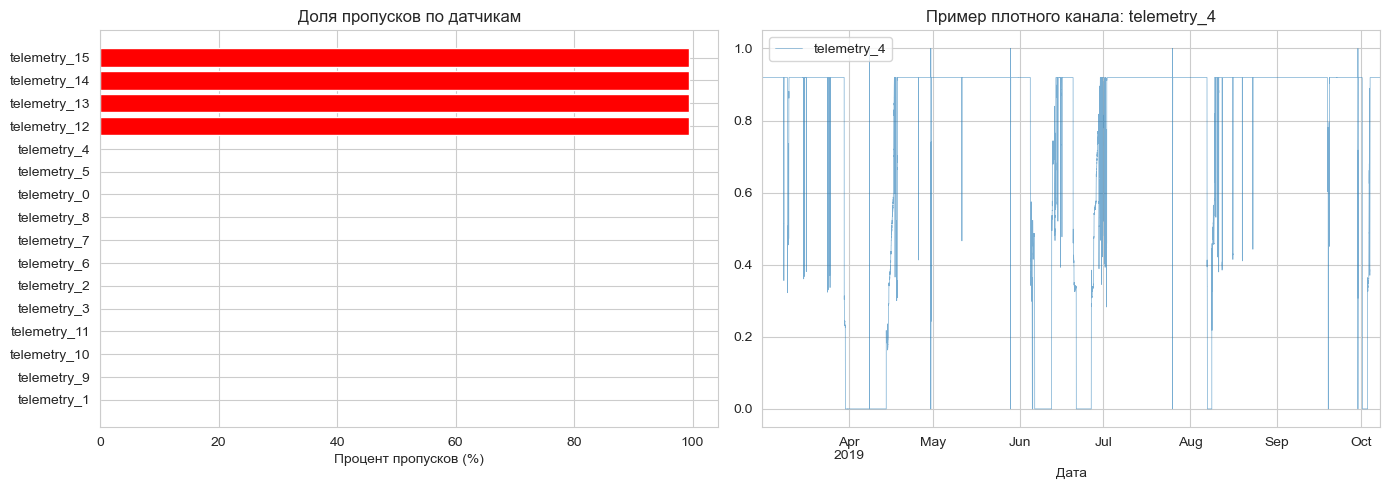

In [5]:
print("\n" + "="*60)
print("АНАЛИЗ ПРОПУСКОВ")
print("="*60)

missing_stats = pd.DataFrame({
    "sensor": sensor_columns,
    "missing_pct": [df_sensors[c].isna().mean() * 100 for c in sensor_columns]
}).sort_values("missing_pct", ascending=False)

missing_stats["category"] = missing_stats["missing_pct"].apply(
    lambda x: "sparse" if x > 90 else ("dense" if x < 5 else "medium")
)
print(missing_stats.head(10))

dense_sensors = missing_stats[missing_stats["category"] == "dense"]["sensor"].tolist()
sparse_sensors = missing_stats[missing_stats["category"] == "sparse"]["sensor"].tolist()
print(f"\nПлотные каналы: {len(dense_sensors)}")
print(f"Разреженные каналы: {len(sparse_sensors)}")

# Визуализация пропусков
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

missing_stats_sorted = missing_stats.sort_values("missing_pct")
axes[0].barh(missing_stats_sorted["sensor"], missing_stats_sorted["missing_pct"], 
             color=['red' if p > 95 else 'orange' if p > 10 else 'green' for p in missing_stats_sorted["missing_pct"]])
axes[0].set_xlabel("Процент пропусков (%)")
axes[0].set_title("Доля пропусков по датчикам")

# Пример плотного канала
sample_sensor = dense_sensors[0]
df_sensors.plot(x="datetime", y=sample_sensor, ax=axes[1], alpha=0.6, linewidth=0.5)
axes[1].set_title(f"Пример плотного канала: {sample_sensor}")
axes[1].set_xlabel("Дата")

plt.tight_layout()
plt.show()

<p>Как видно, 12 13 14 и 15 каналы телеметрии имеют большое кол-во пропусков (> 90%)</p>
Предлагаемый вариант обработки пропусков
Плотные каналы (мало пропусков)
Метод: линейная интерполяция → forward fill → backward fill

Почему: пропуски кратковременные (1-3 мин), процесс инерционный, значения меняются плавно

Разреженные каналы (много пропусков, >90%)
Метод:

_last - последнее известное значение

_age - сколько минут прошло с момента последнего измерения

Почему: редкие ручные измерения или события, значение константа между замерами, важна "свежесть" данных


АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
Статистика интервалов между измерениями:
count     1772.000000
mean       169.164786
std        784.088290
min         60.000000
25%        120.000000
50%        120.000000
75%        120.000000
max      26430.000000
Name: interval_min, dtype: float64

Статистика распределения целевой переменной:
  Асимметрия (Skewness): 0.5496
  Эксцесс (Kurtosis): 0.4193
  Тест Жака-Бера: stat=102.2461, p-value=0.000000
  Тест Шапиро-Уилка: stat=0.9699, p-value=0.000000


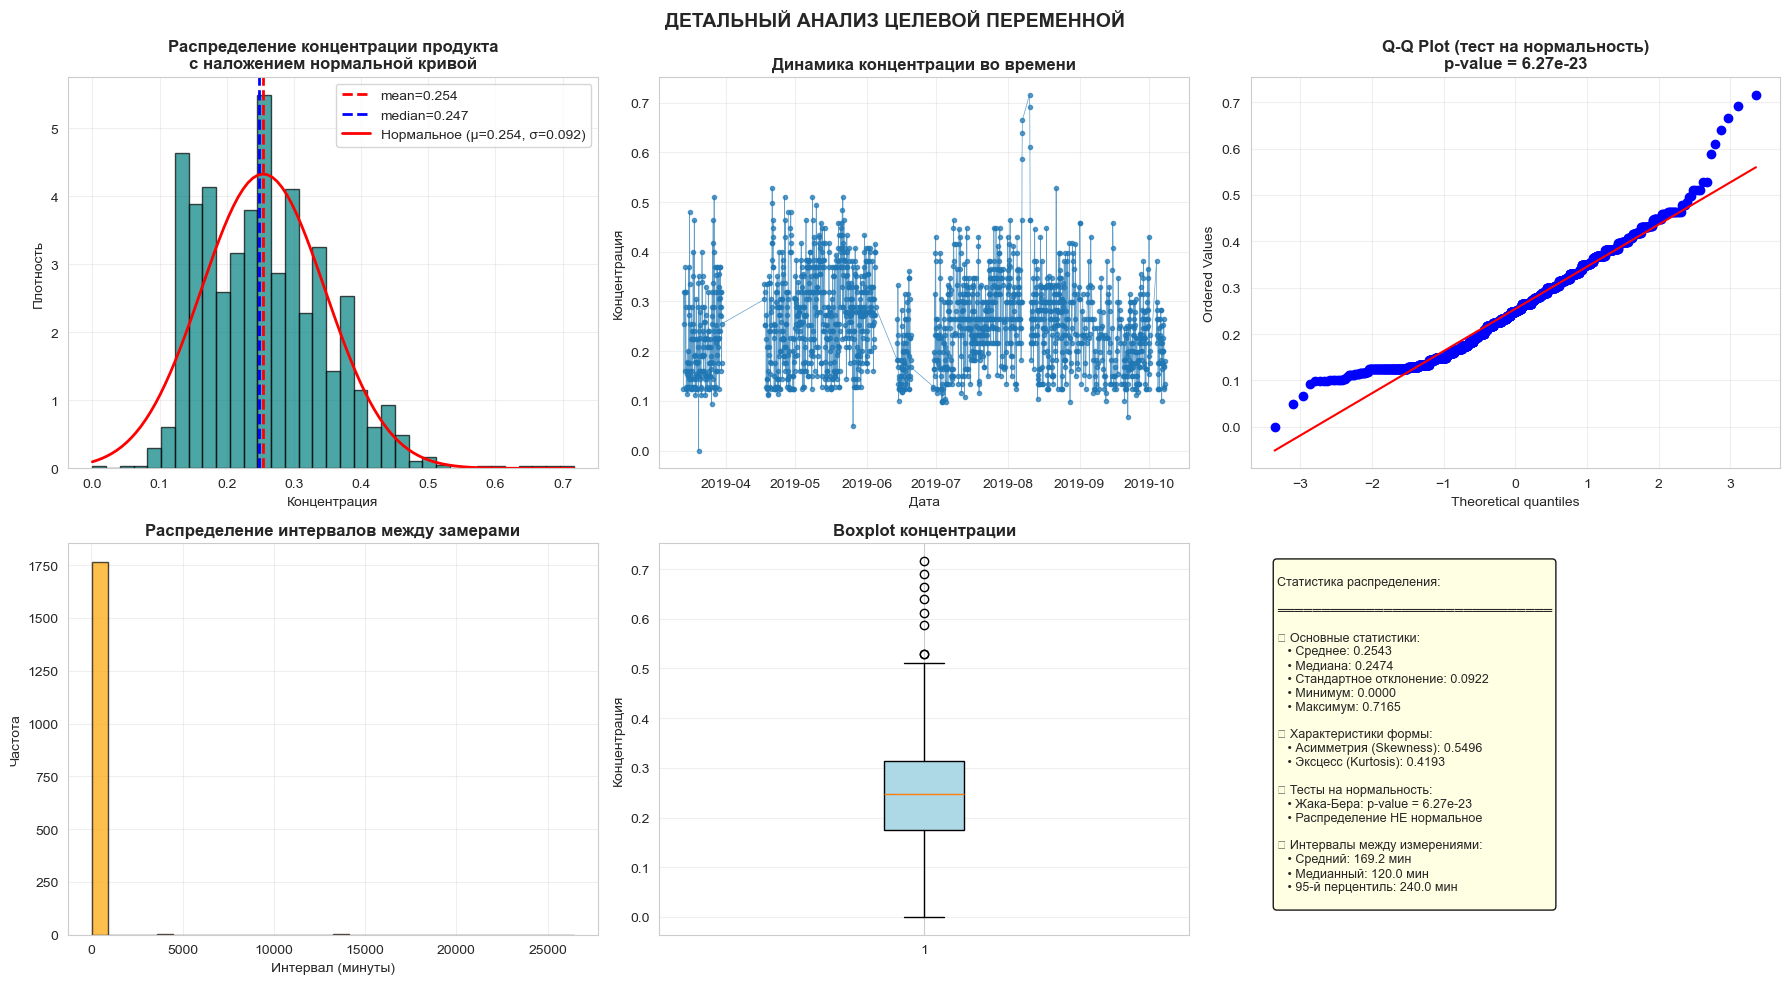


ИНТЕРПРЕТАЦИЯ ФОРМЫ РАСПРЕДЕЛЕНИЯ
✅ Положительная асимметрия (0.550): распределение смещено влево
   → Большинство значений ниже среднего, есть редкие высокие значения
✅ Нормальный эксцесс (0.419)


In [11]:
print("\n" + "="*60)
print("АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ")
print("="*60)

from scipy import stats
import numpy as np

df_lab_sorted = df_lab.sort_values("datetime").copy()
df_lab_sorted["interval_min"] = df_lab_sorted["datetime"].diff().dt.total_seconds() / 60

print("Статистика интервалов между измерениями:")
print(df_lab_sorted["interval_min"].describe())

# Статистика для теста нормальности
target_data = df_lab["target"].dropna()
shapiro_stat, shapiro_p = stats.shapiro(target_data) if len(target_data) < 5000 else (None, None)
jb_stat, jb_p = stats.jarque_bera(target_data)
skewness = stats.skew(target_data)
kurtosis = stats.kurtosis(target_data)

print(f"\nСтатистика распределения целевой переменной:")
print(f"  Асимметрия (Skewness): {skewness:.4f}")
print(f"  Эксцесс (Kurtosis): {kurtosis:.4f}")
print(f"  Тест Жака-Бера: stat={jb_stat:.4f}, p-value={jb_p:.6f}")
if shapiro_stat:
    print(f"  Тест Шапиро-Уилка: stat={shapiro_stat:.4f}, p-value={shapiro_p:.6f}")

# Визуализация
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Распределение целевой переменной с нормальной кривой
axes[0, 0].hist(df_lab["target"], bins=35, color='teal', alpha=0.7, edgecolor='black', density=True)
axes[0, 0].axvline(df_lab["target"].mean(), color='red', linestyle='--', linewidth=2, label=f'mean={df_lab["target"].mean():.3f}')
axes[0, 0].axvline(df_lab["target"].median(), color='blue', linestyle='--', linewidth=2, label=f'median={df_lab["target"].median():.3f}')

# Добавляем теоретическое нормальное распределение
mu, std = df_lab["target"].mean(), df_lab["target"].std()
x = np.linspace(df_lab["target"].min(), df_lab["target"].max(), 100)
normal_pdf = stats.norm.pdf(x, mu, std)
axes[0, 0].plot(x, normal_pdf, 'r-', linewidth=2, label=f'Нормальное (μ={mu:.3f}, σ={std:.3f})')

axes[0, 0].set_title("Распределение концентрации продукта\nс наложением нормальной кривой", fontweight='bold')
axes[0, 0].set_xlabel("Концентрация")
axes[0, 0].set_ylabel("Плотность")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Временной ряд
axes[0, 1].plot(df_lab_sorted["datetime"], df_lab_sorted["target"], 'o-', markersize=3, linewidth=0.5, alpha=0.7)
axes[0, 1].set_title("Динамика концентрации во времени", fontweight='bold')
axes[0, 1].set_xlabel("Дата")
axes[0, 1].set_ylabel("Концентрация")
axes[0, 1].grid(True, alpha=0.3)

# 3. Q-Q Plot (квантиль-квантиль график)
stats.probplot(target_data, dist="norm", plot=axes[0, 2])
axes[0, 2].set_title(f"Q-Q Plot (тест на нормальность)\np-value = {jb_p:.2e}", fontweight='bold')
axes[0, 2].grid(True, alpha=0.3)

# 4. Гистограмма интервалов
axes[1, 0].hist(df_lab_sorted["interval_min"].dropna(), bins=30, color='orange', alpha=0.7, edgecolor='black')
axes[1, 0].set_title("Распределение интервалов между замерами", fontweight='bold')
axes[1, 0].set_xlabel("Интервал (минуты)")
axes[1, 0].set_ylabel("Частота")
axes[1, 0].grid(True, alpha=0.3)

# 5. Boxplot
box = axes[1, 1].boxplot(df_lab["target"], patch_artist=True)
box['boxes'][0].set_facecolor('lightblue')
axes[1, 1].set_title("Boxplot концентрации", fontweight='bold')
axes[1, 1].set_ylabel("Концентрация")
axes[1, 1].grid(True, alpha=0.3, axis='y')

# 6. Текстовая статистика
stats_text = f"""
Статистика распределения:

═══════════════════════════════

📊 Основные статистики:
   • Среднее: {df_lab["target"].mean():.4f}
   • Медиана: {df_lab["target"].median():.4f}
   • Стандартное отклонение: {df_lab["target"].std():.4f}
   • Минимум: {df_lab["target"].min():.4f}
   • Максимум: {df_lab["target"].max():.4f}

📈 Характеристики формы:
   • Асимметрия (Skewness): {skewness:.4f}
   • Эксцесс (Kurtosis): {kurtosis:.4f}

🔬 Тесты на нормальность:
   • Жака-Бера: p-value = {jb_p:.2e}
   • {'Распределение НЕ нормальное' if jb_p < 0.05 else 'Распределение нормальное'}

📋 Интервалы между измерениями:
   • Средний: {df_lab_sorted["interval_min"].mean():.1f} мин
   • Медианный: {df_lab_sorted["interval_min"].median():.1f} мин
   • 95-й перцентиль: {df_lab_sorted["interval_min"].quantile(0.95):.1f} мин
"""

axes[1, 2].text(0.05, 0.95, stats_text, transform=axes[1, 2].transAxes,
                fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9, edgecolor='black'))
axes[1, 2].set_xlim(0, 1)
axes[1, 2].set_ylim(0, 1)
axes[1, 2].axis('off')

plt.suptitle("ДЕТАЛЬНЫЙ АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Дополнительный анализ асимметрии
print("\n" + "="*60)
print("ИНТЕРПРЕТАЦИЯ ФОРМЫ РАСПРЕДЕЛЕНИЯ")
print("="*60)

if skewness > 0.5:
    print(f"✅ Положительная асимметрия ({skewness:.3f}): распределение смещено влево")
    print("   → Большинство значений ниже среднего, есть редкие высокие значения")
elif skewness < -0.5:
    print(f"✅ Отрицательная асимметрия ({skewness:.3f}): распределение смещено вправо")
    print("   → Большинство значений выше среднего, есть редкие низкие значения")
else:
    print(f"✅ Симметричное распределение ({skewness:.3f})")

if kurtosis > 0.5:
    print(f"✅ Положительный эксцесс ({kurtosis:.3f}): острый пик, тяжелые хвосты")
    print("   → Распределение более островершинное, чем нормальное")
elif kurtosis < -0.5:
    print(f"✅ Отрицательный эксцесс ({kurtosis:.3f}): плоская вершина, легкие хвосты")
    print("   → Распределение более плоское, чем нормальное")
else:
    print(f"✅ Нормальный эксцесс ({kurtosis:.3f})")

<p>Целевая переменная не проходит тест на нормальность распределения, есть положительная ассиметрий, что значит что большинство значений ниже среднего</p>
<p>Выбросов по boxplot немного, всего 7</p>
<p>Распределение интервалов равномерное</p>


НАСТРОЙКА ВРЕМЕННОЙ ЗАДЕРЖКИ
Используемая временная задержка: 15 минут

Анализ корреляций с задержкой 15 минут:

Топ-10 корреляций с задержкой 15 минут:
      sensor  correlation  abs_corr  n_samples
 telemetry_0    -0.177327  0.177327       1772
 telemetry_3    -0.127028  0.127028       1772
 telemetry_9    -0.119727  0.119727       1772
 telemetry_6    -0.090049  0.090049       1772
 telemetry_8     0.089491  0.089491       1772
telemetry_11    -0.088863  0.088863       1772
telemetry_10    -0.072430  0.072430       1772
 telemetry_5    -0.071087  0.071087       1772
 telemetry_4    -0.070214  0.070214       1771
 telemetry_7    -0.044736  0.044736       1772
 telemetry_1    -0.044257  0.044257       1772
 telemetry_2    -0.010546  0.010546       1772

Ключевые датчики для моделирования: ['telemetry_0', 'telemetry_3', 'telemetry_9', 'telemetry_6', 'telemetry_8', 'telemetry_11', 'telemetry_10', 'telemetry_5', 'telemetry_4', 'telemetry_7', 'telemetry_1', 'telemetry_2']


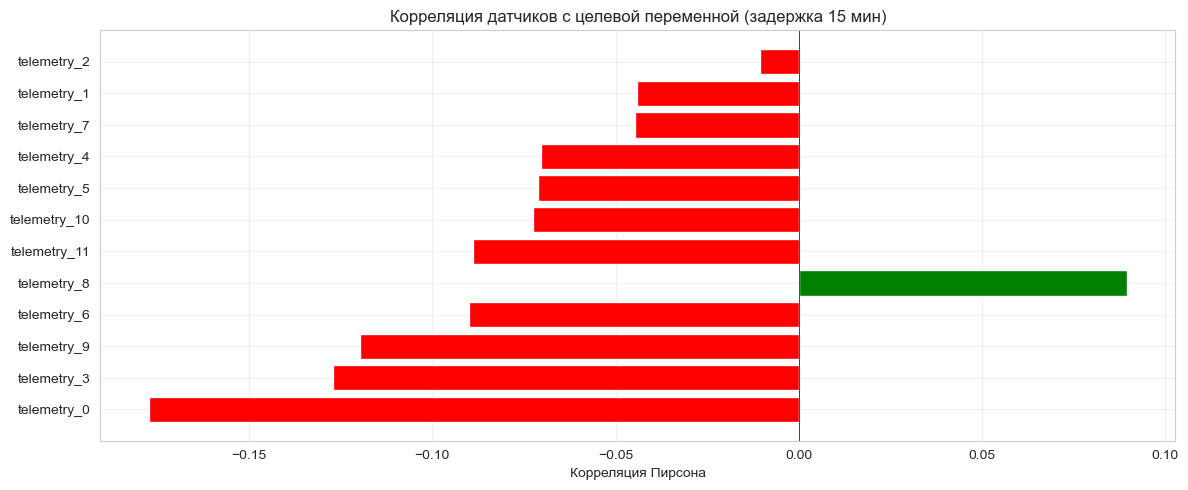

In [16]:
# УЧЕТ ВРЕМЕННОЙ ЗАДЕРЖКИ (ФИКСИРОВАННОЕ ЗНАЧЕНИЕ)
print("\n" + "="*60)
print("НАСТРОЙКА ВРЕМЕННОЙ ЗАДЕРЖКИ")
print("="*60)

# Используем стандартную задержку 15 минут 
OPTIMAL_DELAY = 15
print(f"Используемая временная задержка: {OPTIMAL_DELAY} минут")

print("\nАнализ корреляций с задержкой 15 минут:")

sensors_indexed = df_sensors.set_index('datetime')
target_sorted = df_lab.sort_values('datetime')

correlations_list = []
for sensor in dense_sensors:  
    matched_pairs = []
    for _, row in target_sorted.iterrows():
        target_time = row['datetime']
        target_val = row['target']
        
        # Время с учетом задержки
        sensor_time = target_time - pd.Timedelta(minutes=OPTIMAL_DELAY)
        
        if sensor_time in sensors_indexed.index:
            sensor_val = sensors_indexed.loc[sensor_time, sensor]
        else:
            idx = sensors_indexed.index.get_indexer([sensor_time], method='nearest')[0]
            if idx >= 0 and idx < len(sensors_indexed):
                time_diff = abs(sensors_indexed.index[idx] - sensor_time)
                if time_diff <= pd.Timedelta(minutes=2):
                    sensor_val = sensors_indexed.iloc[idx][sensor]
                else:
                    continue
            else:
                continue
        
        if pd.notna(sensor_val):
            matched_pairs.append((sensor_val, target_val))
    
    if len(matched_pairs) > 10:
        sensor_vals, target_vals = zip(*matched_pairs)
        corr = np.corrcoef(sensor_vals, target_vals)[0, 1]
        correlations_list.append({
            'sensor': sensor,
            'correlation': corr,
            'abs_corr': abs(corr),
            'n_samples': len(matched_pairs)
        })

corr_df = pd.DataFrame(correlations_list).sort_values('abs_corr', ascending=False)
print("\nТоп-10 корреляций с задержкой 15 минут:")
print(corr_df.to_string(index=False))

key_sensors = corr_df['sensor'].tolist()
print(f"\nКлючевые датчики для моделирования: {key_sensors}")

# Визуализация корреляций
fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(corr_df['sensor'][:15], corr_df['correlation'][:15], 
        color=['green' if c > 0 else 'red' for c in corr_df['correlation'][:15]])
ax.set_xlabel('Корреляция Пирсона')
ax.set_title(f'Корреляция датчиков с целевой переменной (задержка {OPTIMAL_DELAY} мин)')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. ИНЖИНИРИНГ ПРИЗНАКОВ

In [17]:
# 6. ПОДГОТОВКА ДАННЫХ И ИНЖИНИРИНГ ПРИЗНАКОВ

print("\n" + "="*60)
print("ИНЖИНИРИНГ ПРИЗНАКОВ")
print("="*60)

def prepare_sensor_data(sensors_df, dense_list, sparse_list):
    """Подготовка данных датчиков с обработкой пропусков"""
    df = sensors_df.sort_values("datetime").copy()
    
    # Плотные каналы: интерполяция
    for col in dense_list:
        if col in df.columns:
            df[col] = df[col].interpolate(method='linear', limit=3).fillna(method='ffill').fillna(method='bfill')
    
    # Разреженные каналы: last value + age
    for col in sparse_list:
        if col in df.columns:
            df[f"{col}_last"] = df[col].fillna(method='ffill')
            # Возраст значения в минутах
            last_valid = df[col].notna()
            last_valid_idx = last_valid[last_valid].index
            if len(last_valid_idx) > 0:
                last_time = df["datetime"].copy()
                for i in range(len(last_time)):
                    prev_valid = last_valid_idx[last_valid_idx <= i]
                    if len(prev_valid) > 0:
                        last_time.iloc[i] = df["datetime"].iloc[prev_valid[-1]]
                df[f"{col}_age"] = (df["datetime"] - last_time).dt.total_seconds() / 60
            else:
                df[f"{col}_age"] = 0
    
    # Временные признаки
    df["hour"] = df["datetime"].dt.hour
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["day_of_week"] = df["datetime"].dt.dayofweek
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    
    return df

prepared_train = prepare_sensor_data(df_sensors, dense_sensors, sparse_sensors)
prepared_test = prepare_sensor_data(df_sensors_test, dense_sensors, sparse_sensors)


ИНЖИНИРИНГ ПРИЗНАКОВ


In [27]:
def create_features_dataset(sensors_prepared, target_df, delay_min=15, 
                            key_features=None, lag_list = [1, 5, 15, 30, 45, 60, 120, 180, 240, 360, 720, 1440],
                            windows = [5, 10, 15, 20, 30, 45, 60, 90, 120, 180, 240, 360, 480, 720, 1440]):
    """Создание расширенного набора признаков"""
    if key_features is None:
        key_features = dense_sensors
    
    # Синхронизация
    target_aligned = target_df.sort_values("datetime").copy()
    target_aligned["process_time"] = target_aligned["datetime"] - pd.Timedelta(minutes=delay_min)
    
    sensors_indexed = sensors_prepared.set_index("datetime")
    result = target_aligned[["datetime", "process_time", "target"]].copy()
    
    feature_dict = {}
    
    # Базовые признаки
    base_cols = key_features + ["hour", "hour_sin", "hour_cos", "day_of_week", "is_weekend"]
                #[f"{c}_last" for c in sparse_sensors] + \
                #[f"{c}_age" for c in sparse_sensors] + \
                
    
    for col in base_cols:
        if col in sensors_indexed.columns:
            feature_dict[col] = sensors_indexed[col].reindex(target_aligned["process_time"]).values
    
    # Лаговые признаки
    for feat in key_features:
        if feat in sensors_indexed.columns:
            series = sensors_indexed[feat]
            for lag in lag_list:
                lagged = series.shift(lag).reindex(target_aligned["process_time"])
                feature_dict[f"{feat}_lag{lag}"] = lagged.values
    
    # Скользящие статистики
    for feat in key_features:
        if feat in sensors_indexed.columns:
            series = sensors_indexed[feat]
            for w in windows:
                rolling = series.rolling(w, min_periods=w//2)
                feature_dict[f"{feat}_mean{w}"] = rolling.mean().reindex(target_aligned["process_time"]).values
                feature_dict[f"{feat}_std{w}"] = rolling.std().reindex(target_aligned["process_time"]).values
    
    features_df = pd.DataFrame(feature_dict)
    result = pd.concat([result, features_df], axis=1)
    
    return result

# Создаем финальные датасеты
print("Создание обучающего датасета...")
train_features = create_features_dataset(prepared_train, df_lab, delay_min=OPTIMAL_DELAY,
                                          key_features=key_sensors)

print("Создание тестового датасета...")
test_features = create_features_dataset(prepared_test, df_lab_test, delay_min=OPTIMAL_DELAY,
                                         key_features=key_sensors)

# Очистка от NaN
train_features = train_features.dropna()
test_features = test_features.dropna()

feature_columns = [c for c in train_features.columns if c not in ["datetime", "process_time", "target"]]

print(f"\nФинальный датасет:")
print(f"  Train: {train_features.shape}")
print(f"  Test: {test_features.shape}")
print(f"  Признаков: {len(feature_columns)}")

# Разделение train на train/val
split_idx = int(len(train_features) * 0.8)
X_train = train_features.iloc[:split_idx][feature_columns]
y_train = train_features.iloc[:split_idx]["target"]
X_valid = train_features.iloc[split_idx:][feature_columns]
y_valid = train_features.iloc[split_idx:]["target"]

X_test = test_features[feature_columns]
y_test = test_features["target"]

print(f"  Train samples: {len(X_train)}")
print(f"  Validation samples: {len(X_valid)}")
print(f"  Test samples: {len(X_test)}")

Создание обучающего датасета...
Создание тестового датасета...

Финальный датасет:
  Train: (1772, 524)
  Test: (307, 524)
  Признаков: 521
  Train samples: 1417
  Validation samples: 355
  Test samples: 307


<p>Снижать размерность признаков не требуется, т.к. тогда потеряется возможность их интерпретации</p>
<p>1. Базовые признаки (key_features)
Выбор: топ-8 датчиков по корреляции с target

Смысл: основные параметры процесса, напрямую влияют на качество

Вклад: baseline предсказания, мгновенная реакция

2. Лаговые признаки (lag_list: 1 мин → 24 часа)
Выбор: экспоненциально растущие лаги

Смысл: инерционность процесса (тепловая инерция печи)

Вклад: улавливают динамику, предсказывают по предыстории

3. Скользящие статистики (mean, std)
Выбор: окна от 5 мин до 24 часов

Смысл: средний режим работы и стабильность процесса

Вклад: сглаживают шум, показывают тренды и отклонения

4. Признаки разреженных каналов (_last, _age)
Выбор: последнее значение + возраст

Смысл: редкие ручные измерения (состав сырья, настройки)

Вклад: учитывают качество исходных материалов

5. Временные признаки (hour, day_of_week)
Выбор: час, день недели, sin/cos кодирование

Смысл: суточные и недельные циклы производства

Вклад: разные режимы работы в разное время</p>

# 3. ОБУЧЕНИЕ И ОЦЕНКА МОДЕЛЕЙ

In [28]:
# ОБУЧЕНИЕ МОДЕЛЕЙ
print("\n" + "="*60)
print("ОБУЧЕНИЕ МОДЕЛЕЙ")
print("="*60)

def evaluate_model(y_true, y_pred):
    """Расчет метрик качества"""
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MAPE": np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-6))) * 100
    }


ОБУЧЕНИЕ МОДЕЛЕЙ


In [29]:
# Модели
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [30]:
models = {
    "Ridge": Ridge(alpha=1.0, random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=1000, max_depth=8, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=1000, max_depth=4, learning_rate=0.05, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_valid)
    metrics = evaluate_model(y_valid, preds)
    results[name] = metrics
    print(f"\n{name}:")
    print(f"  MAE: {metrics['MAE']:.4f}")
    print(f"  RMSE: {metrics['RMSE']:.4f}")
    print(f"  R2: {metrics['R2']:.4f}")

print("\n" + "="*60)
print("Модели обучены")
print("="*60)


Ridge:
  MAE: 0.0706
  RMSE: 0.0874
  R2: -0.3065

RandomForest:
  MAE: 0.0706
  RMSE: 0.0872
  R2: -0.3033

GradientBoosting:
  MAE: 0.0729
  RMSE: 0.0894
  R2: -0.3685

Модели обучены


In [31]:
# ОЦЕНКА КАЧЕСТВА МОДЕЛЕЙ 

print("\n" + "="*80)
print("РАСШИРЕННАЯ ОЦЕНКА КАЧЕСТВА МОДЕЛЕЙ")
print("="*80)

# Дополнительные метрики
def extended_metrics(y_true, y_pred):
    """Расширенный набор метрик качества"""
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Базовые метрики
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + 1e-6))) * 100
    
    # WAPE (Weighted Absolute Percentage Error)
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100
    
    # Метрики направления
    true_diff = np.diff(y_true)
    pred_diff = np.diff(y_pred)
    
    if len(true_diff) > 0:
        directional_accuracy = np.mean((true_diff * pred_diff) > 0)
        up_mask = true_diff > 0
        down_mask = true_diff < 0
        up_recall = np.mean((pred_diff[up_mask] > 0)) if up_mask.any() else 0
        down_recall = np.mean((pred_diff[down_mask] < 0)) if down_mask.any() else 0
    else:
        directional_accuracy = 0
        up_recall = 0
        down_recall = 0
    
    # Дополнительные метрики
    max_error = np.max(np.abs(y_true - y_pred))
    median_absolute_error = np.median(np.abs(y_true - y_pred))
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape,
        "WAPE": wape,
        "Directional_Accuracy": directional_accuracy,
        "Up_Recall": up_recall,
        "Down_Recall": down_recall,
        "Max_Error": max_error,
        "Median_AE": median_absolute_error
    }

# Оценка всех моделей
all_results = {}
all_predictions = {}

for name, model in models.items():
    # Предсказания
    train_pred = model.predict(X_train)
    valid_pred = model.predict(X_valid)
    test_pred = model.predict(X_test)
    
    # Метрики
    train_metrics = extended_metrics(y_train, train_pred)
    valid_metrics = extended_metrics(y_valid, valid_pred)
    test_metrics = extended_metrics(y_test, test_pred)
    
    all_results[name] = {
        "train": train_metrics,
        "valid": valid_metrics,
        "test": test_metrics
    }
    all_predictions[name] = {
        "train": train_pred,
        "valid": valid_pred,
        "test": test_pred
    }
    
    print(f"\n{'='*60}")
    print(f"МОДЕЛЬ: {name}")
    print(f"{'='*60}")
    print(f"\nОБУЧЕНИЕ:")
    print(f"  MAE: {train_metrics['MAE']:.4f} | RMSE: {train_metrics['RMSE']:.4f} | R2: {train_metrics['R2']:.4f}")
    print(f"  MAPE: {train_metrics['MAPE']:.2f}% | WAPE: {train_metrics['WAPE']:.2f}%")
    print(f"\nВАЛИДАЦИЯ:")
    print(f"  MAE: {valid_metrics['MAE']:.4f} | RMSE: {valid_metrics['RMSE']:.4f} | R2: {valid_metrics['R2']:.4f}")
    print(f"  Directional Accuracy: {valid_metrics['Directional_Accuracy']:.2%}")
    print(f"  Up Recall: {valid_metrics['Up_Recall']:.2%} | Down Recall: {valid_metrics['Down_Recall']:.2%}")
    print(f"\nТЕСТ:")
    print(f"  MAE: {test_metrics['MAE']:.4f} | RMSE: {test_metrics['RMSE']:.4f} | R2: {test_metrics['R2']:.4f}")
    print(f"  Directional Accuracy: {test_metrics['Directional_Accuracy']:.2%}")

# Сравнительная таблица
comparison_df = pd.DataFrame({
    name: {
        "Train_MAE": results["train"]["MAE"],
        "Valid_MAE": results["valid"]["MAE"],
        "Test_MAE": results["test"]["MAE"],
        "Test_R2": results["test"]["R2"],
        "Test_Dir_Acc": results["test"]["Directional_Accuracy"],
        "Test_MAPE": results["test"]["MAPE"]
    }
    for name, results in all_results.items()
}).T

print("\n" + "="*80)
print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА МЕТРИК")
print("="*80)
print(comparison_df.round(4).to_string())




РАСШИРЕННАЯ ОЦЕНКА КАЧЕСТВА МОДЕЛЕЙ

МОДЕЛЬ: Ridge

ОБУЧЕНИЕ:
  MAE: 0.0630 | RMSE: 0.0780 | R2: 0.3168
  MAPE: 17728.49% | WAPE: 24.08%

ВАЛИДАЦИЯ:
  MAE: 0.0706 | RMSE: 0.0874 | R2: -0.3065
  Directional Accuracy: 48.02%
  Up Recall: 48.19% | Down Recall: 53.25%

ТЕСТ:
  MAE: 0.0636 | RMSE: 0.0800 | R2: 0.0241
  Directional Accuracy: 54.25%

МОДЕЛЬ: RandomForest

ОБУЧЕНИЕ:
  MAE: 0.0382 | RMSE: 0.0471 | R2: 0.7512
  MAPE: 9183.12% | WAPE: 14.61%

ВАЛИДАЦИЯ:
  MAE: 0.0706 | RMSE: 0.0872 | R2: -0.3033
  Directional Accuracy: 48.02%
  Up Recall: 52.41% | Down Recall: 49.11%

ТЕСТ:
  MAE: 0.0724 | RMSE: 0.0859 | R2: -0.1255
  Directional Accuracy: 58.17%

МОДЕЛЬ: GradientBoosting

ОБУЧЕНИЕ:
  MAE: 0.0036 | RMSE: 0.0045 | R2: 0.9977
  MAPE: 592.29% | WAPE: 1.38%

ВАЛИДАЦИЯ:
  MAE: 0.0729 | RMSE: 0.0894 | R2: -0.3685
  Directional Accuracy: 47.46%
  Up Recall: 50.60% | Down Recall: 49.70%

ТЕСТ:
  MAE: 0.0716 | RMSE: 0.0858 | R2: -0.1231
  Directional Accuracy: 52.94%

СРАВНИТЕЛЬНАЯ ТАБЛИ


АНАЛИЗ ОСТАТКОВ


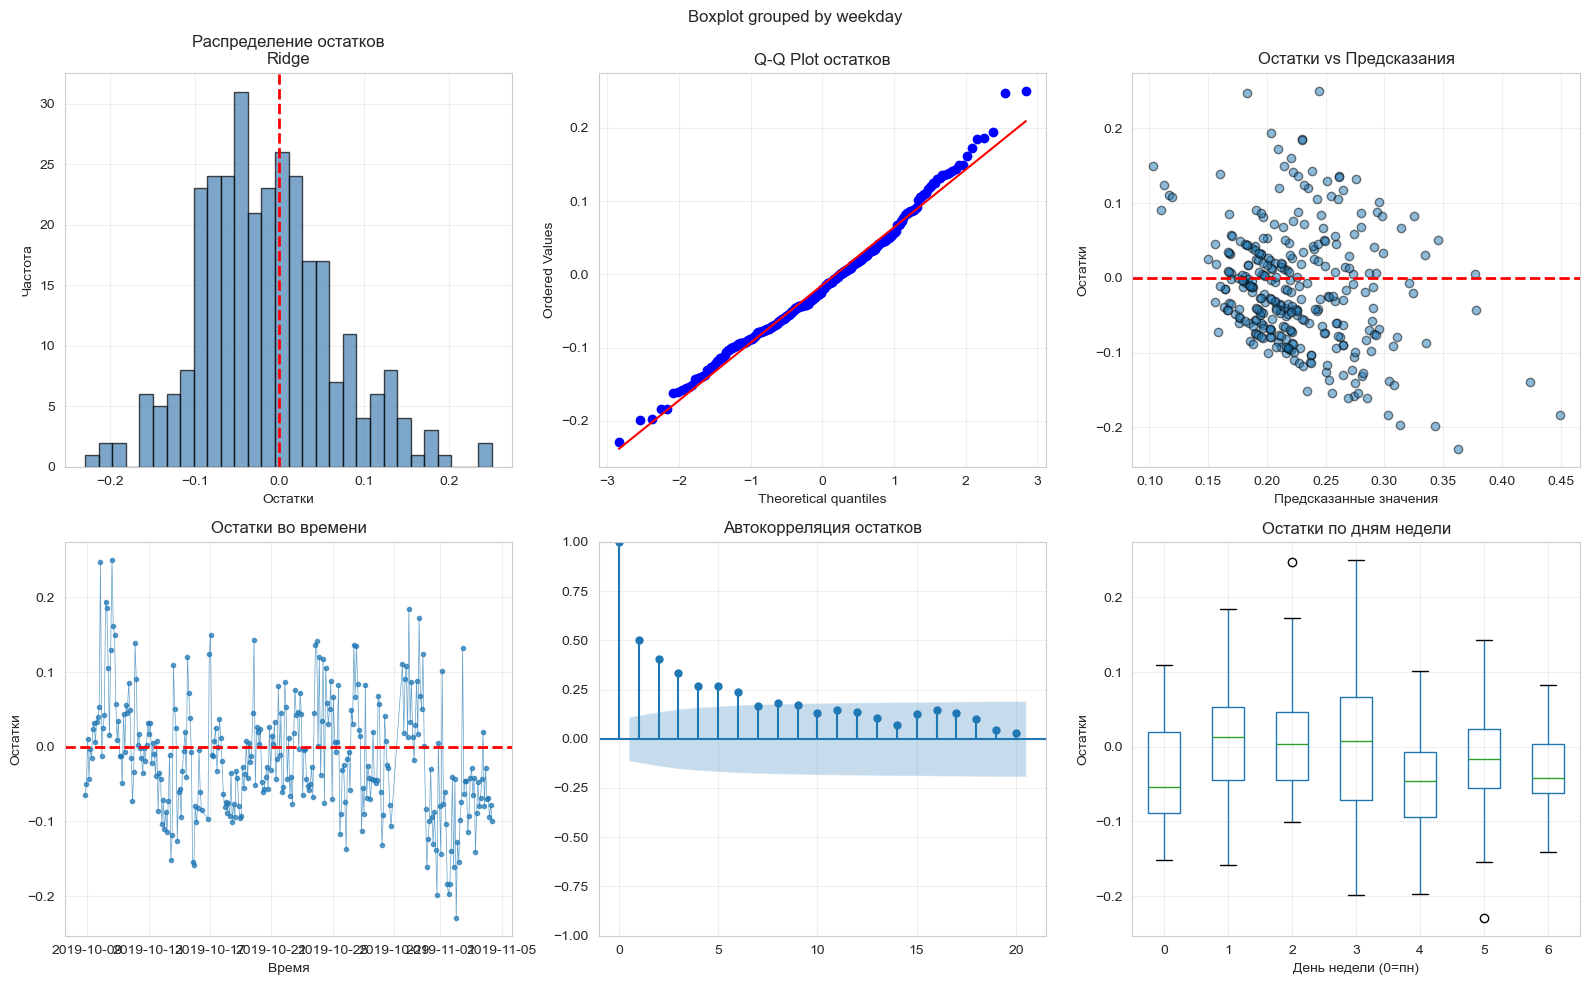


СТАТИСТИЧЕСКИЕ ТЕСТЫ ОСТАТКОВ

1. Тест Жака-Бера (нормальность распределения):
   Статистика: 11.2820
   p-value: 0.003549
   Вывод: Распределение НЕ нормальное

2. Тест Льюнга-Бокса (автокорреляция):
       lb_stat     lb_pvalue
5   209.454259  2.693045e-43
10  261.165058  2.429192e-50
15  284.081712  1.125085e-51
   Вывод: Есть автокорреляция

3. Тест Бройша-Пагана (гетероскедастичность):
   Статистика: 307.0000
   p-value: 1.000000
   Вывод: Нет гетероскедастичности


In [32]:
# АНАЛИЗ ОСТАТКОВ

print("\n" + "="*80)
print("АНАЛИЗ ОСТАТКОВ")
print("="*80)

# Выбираем лучшую модель для анализа остатков
best_model_name = min(all_results.keys(), key=lambda x: all_results[x]["test"]["MAE"])
best_model = models[best_model_name]
best_predictions = all_predictions[best_model_name]["test"]

residuals = y_test.values - best_predictions

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Гистограмма остатков
axes[0, 0].hist(residuals, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel("Остатки")
axes[0, 0].set_ylabel("Частота")
axes[0, 0].set_title(f"Распределение остатков\n{best_model_name}")
axes[0, 0].grid(True, alpha=0.3)

# 2. Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("Q-Q Plot остатков")
axes[0, 1].grid(True, alpha=0.3)

# 3. Остатки vs Предсказания
axes[0, 2].scatter(best_predictions, residuals, alpha=0.5, edgecolors='black')
axes[0, 2].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[0, 2].set_xlabel("Предсказанные значения")
axes[0, 2].set_ylabel("Остатки")
axes[0, 2].set_title("Остатки vs Предсказания")
axes[0, 2].grid(True, alpha=0.3)

# 4. Остатки во времени
time_steps = test_features["process_time"].values
axes[1, 0].plot(time_steps, residuals, 'o-', markersize=3, linewidth=0.5, alpha=0.7)
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel("Время")
axes[1, 0].set_ylabel("Остатки")
axes[1, 0].set_title("Остатки во времени")
axes[1, 0].grid(True, alpha=0.3)

# 5. Автокорреляция остатков
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals, lags=20, ax=axes[1, 1])
axes[1, 1].set_title("Автокорреляция остатков")
axes[1, 1].grid(True, alpha=0.3)

# 6. Boxplot остатков по дням недели
test_features_plot = test_features.copy()
test_features_plot["residuals"] = residuals
test_features_plot["weekday"] = test_features_plot["process_time"].dt.dayofweek
test_features_plot.boxplot(column="residuals", by="weekday", ax=axes[1, 2])
axes[1, 2].set_title("Остатки по дням недели")
axes[1, 2].set_xlabel("День недели (0=пн)")
axes[1, 2].set_ylabel("Остатки")
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Статистические тесты остатков
print("\n" + "="*60)
print("СТАТИСТИЧЕСКИЕ ТЕСТЫ ОСТАТКОВ")
print("="*60)

# Тест Жака-Бера (нормальность)
jb_stat, jb_pvalue = stats.jarque_bera(residuals)
print(f"\n1. Тест Жака-Бера (нормальность распределения):")
print(f"   Статистика: {jb_stat:.4f}")
print(f"   p-value: {jb_pvalue:.6f}")
print(f"   Вывод: {'Распределение нормальное' if jb_pvalue > 0.05 else 'Распределение НЕ нормальное'}")

# Тест Льюнга-Бокса (автокорреляция)
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(residuals, lags=[5, 10, 15], return_df=True)
print(f"\n2. Тест Льюнга-Бокса (автокорреляция):")
print(lb_test.to_string())
print(f"   Вывод: {'Есть автокорреляция' if lb_test['lb_pvalue'].iloc[0] < 0.05 else 'Нет автокорреляции'}")

# Тест Бройша-Пагана (гетероскедастичность)
from statsmodels.stats.diagnostic import het_breuschpagan
X_with_const = sm.add_constant(X_test)
bp_stat, bp_pvalue, _, _ = het_breuschpagan(residuals, X_with_const)
print(f"\n3. Тест Бройша-Пагана (гетероскедастичность):")
print(f"   Статистика: {bp_stat:.4f}")
print(f"   p-value: {bp_pvalue:.6f}")
print(f"   Вывод: {'Есть гетероскедастичность' if bp_pvalue < 0.05 else 'Нет гетероскедастичности'}")




ВИЗУАЛИЗАЦИЯ ПРОГНОЗОВ


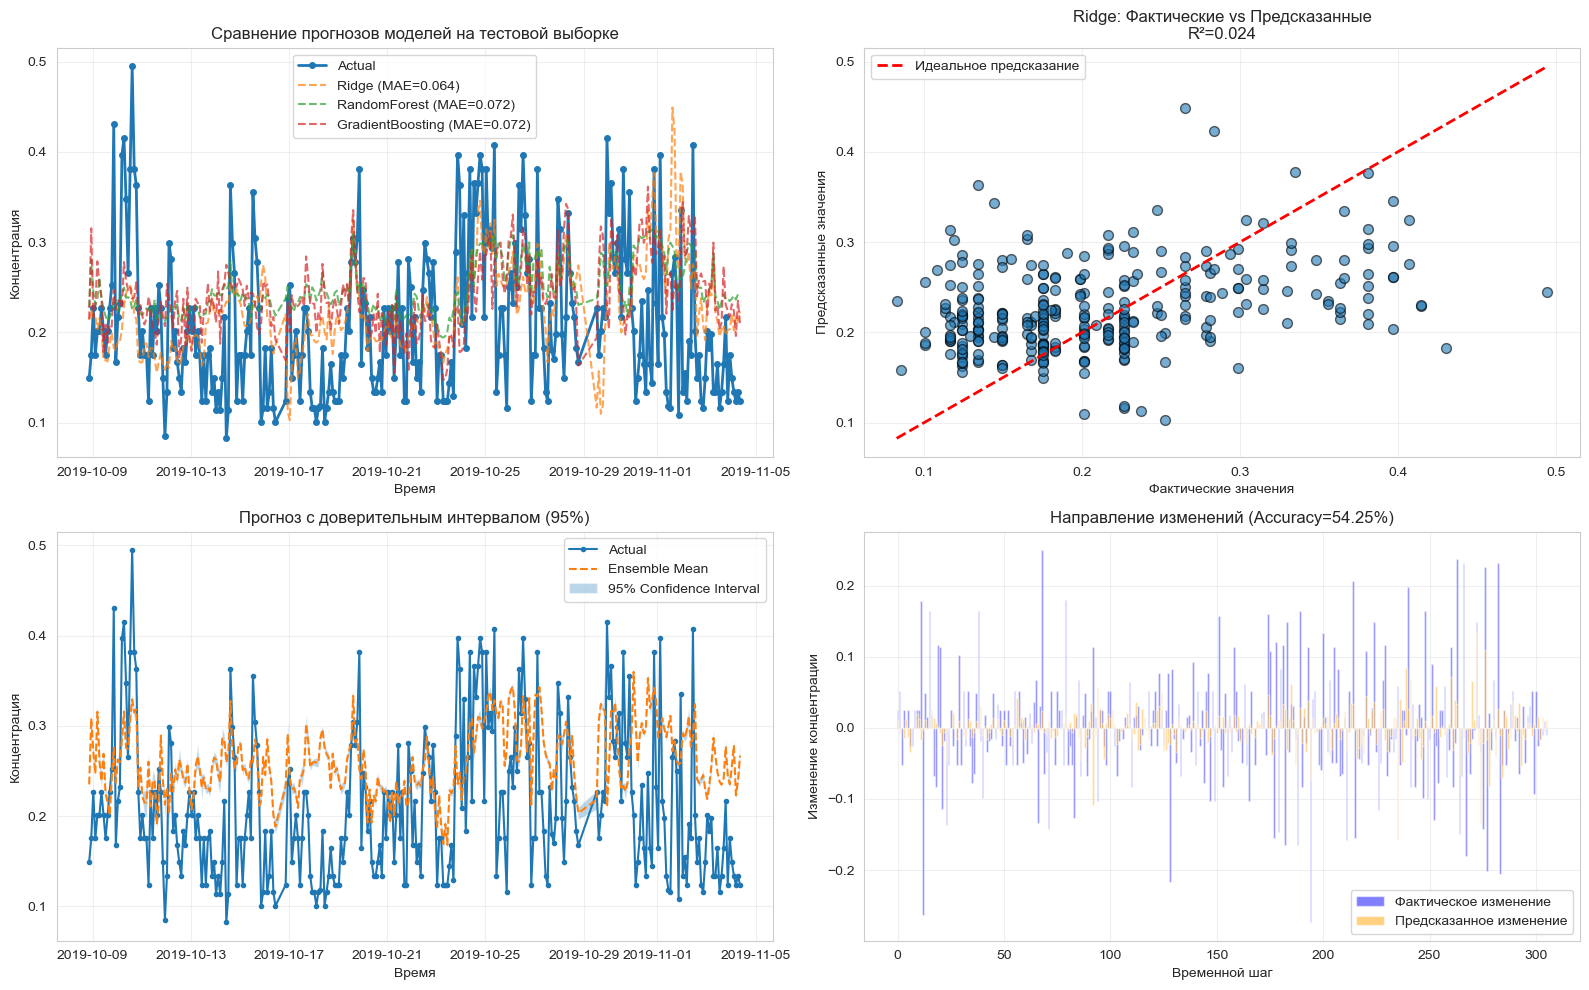

In [33]:
# ВИЗУАЛИЗАЦИЯ ПРОГНОЗОВ

print("\n" + "="*80)
print("ВИЗУАЛИЗАЦИЯ ПРОГНОЗОВ")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Сравнение всех моделей на тесте
axes[0, 0].plot(time_steps, y_test.values, 'o-', label="Actual", linewidth=2, markersize=4)
for name in models.keys():
    axes[0, 0].plot(time_steps, all_predictions[name]["test"], '--', 
                    label=f"{name} (MAE={all_results[name]['test']['MAE']:.3f})", 
                    alpha=0.7, linewidth=1.5)
axes[0, 0].set_xlabel("Время")
axes[0, 0].set_ylabel("Концентрация")
axes[0, 0].set_title("Сравнение прогнозов моделей на тестовой выборке")
axes[0, 0].legend(loc='best')
axes[0, 0].grid(True, alpha=0.3)

# 2. Actual vs Predicted (лучшая модель)
axes[0, 1].scatter(y_test, best_predictions, alpha=0.6, edgecolors='black', s=50)
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
                'r--', linewidth=2, label="Идеальное предсказание")
axes[0, 1].set_xlabel("Фактические значения")
axes[0, 1].set_ylabel("Предсказанные значения")
axes[0, 1].set_title(f"{best_model_name}: Фактические vs Предсказанные\nR²={all_results[best_model_name]['test']['R2']:.3f}")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. График с доверительным интервалом
from sklearn.ensemble import GradientBoostingRegressor
# Оценка неопределенности через ансамбль
n_estimators = 50
predictions_ensemble = []
for seed in range(10):
    model_ensemble = GradientBoostingRegressor(n_estimators=50, max_depth=4, random_state=seed)
    model_ensemble.fit(X_train_imp, y_train)
    predictions_ensemble.append(model_ensemble.predict(X_test_imp))

predictions_array = np.array(predictions_ensemble)
pred_mean = predictions_array.mean(axis=0)
pred_std = predictions_array.std(axis=0)

axes[1, 0].plot(time_steps, y_test.values, 'o-', label="Actual", linewidth=1.5, markersize=3)
axes[1, 0].plot(time_steps, pred_mean, '--', label="Ensemble Mean", linewidth=1.5)
axes[1, 0].fill_between(time_steps, pred_mean - 1.96*pred_std, pred_mean + 1.96*pred_std, 
                         alpha=0.3, label="95% Confidence Interval")
axes[1, 0].set_xlabel("Время")
axes[1, 0].set_ylabel("Концентрация")
axes[1, 0].set_title("Прогноз с доверительным интервалом (95%)")
axes[1, 0].legend(loc='best')
axes[1, 0].grid(True, alpha=0.3)

# 4. Направление изменений
true_direction = np.diff(y_test.values)
pred_direction = np.diff(best_predictions)

correct_direction = (true_direction * pred_direction) > 0
colors = ['green' if cd else 'red' for cd in correct_direction]

axes[1, 1].bar(range(len(correct_direction)), true_direction, alpha=0.5, label="Фактическое изменение", color='blue')
axes[1, 1].bar(range(len(pred_direction)), pred_direction, alpha=0.5, label="Предсказанное изменение", color='orange')
axes[1, 1].set_xlabel("Временной шаг")
axes[1, 1].set_ylabel("Изменение концентрации")
axes[1, 1].set_title(f"Направление изменений (Accuracy={all_results[best_model_name]['test']['Directional_Accuracy']:.2%})")
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ

Вычисление Permutation Importance...

Топ-20 наиболее важных признаков:
             feature  importance      std
 telemetry_4_lag1440    0.002405 0.000355
 telemetry_3_std1440    0.002158 0.000259
  telemetry_4_lag720    0.001224 0.000206
telemetry_1_mean1440    0.000873 0.000130
 telemetry_3_lag1440    0.000771 0.000190
 telemetry_4_std1440    0.000733 0.000131
 telemetry_0_std1440    0.000713 0.000126
  telemetry_1_lag720    0.000677 0.000128
          is_weekend    0.000655 0.000202
  telemetry_6_lag180    0.000635 0.000127
  telemetry_6_lag240    0.000467 0.000096
            hour_sin    0.000343 0.000169
   telemetry_6_lag60    0.000327 0.000187
  telemetry_2_lag720    0.000320 0.000061
 telemetry_2_lag1440    0.000298 0.000072
  telemetry_1_lag360    0.000275 0.000114
  telemetry_3_lag360    0.000262 0.000064
  telemetry_5_lag720    0.000250 0.000127
  telemetry_4_std720    0.000243 0.000066
  telemetry_3_std480    0.000241 0.000043


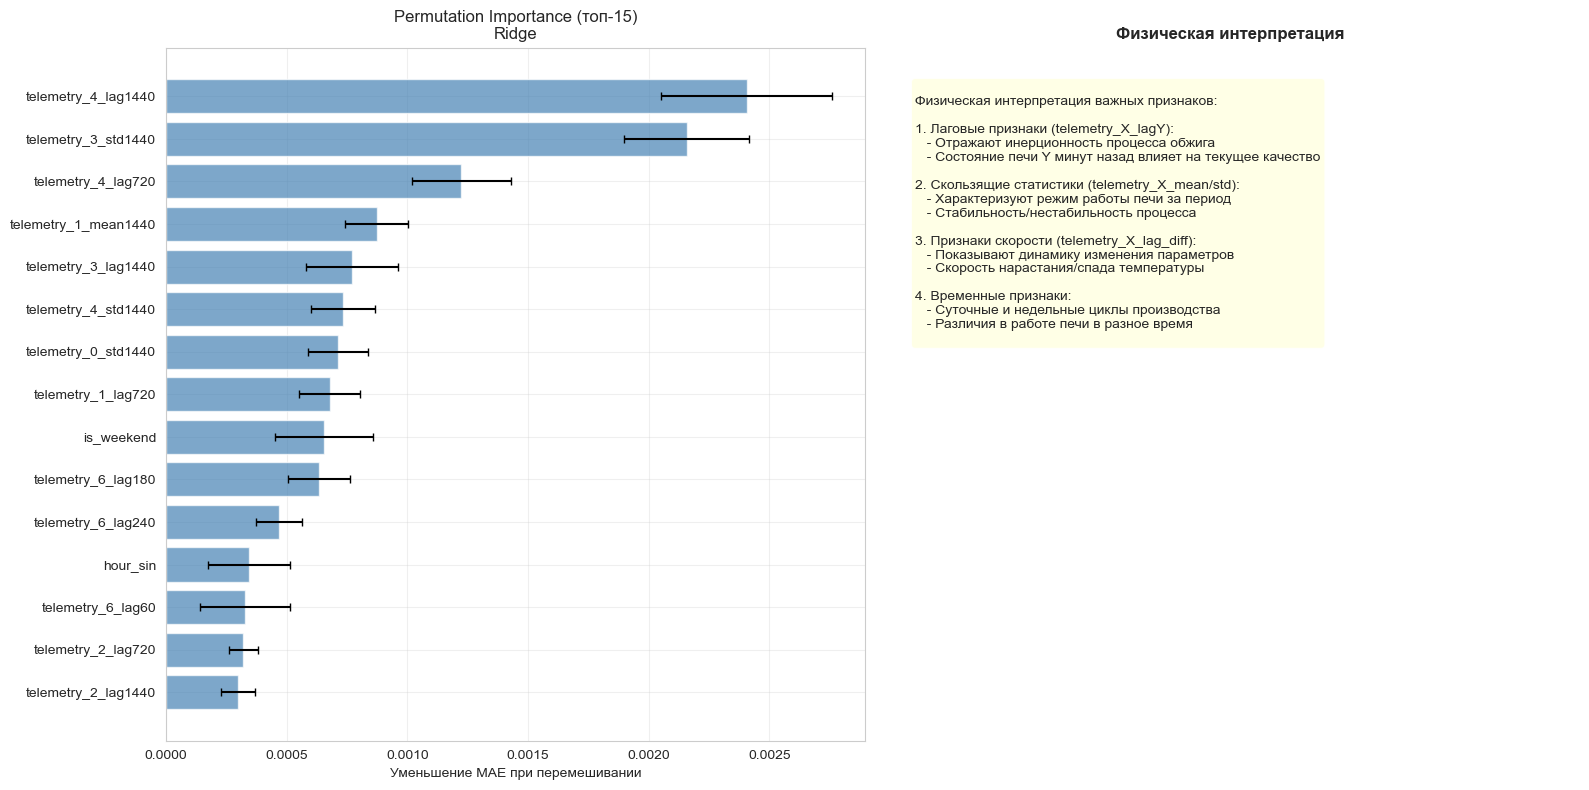

In [34]:
# АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ

print("\n" + "="*80)
print("АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ")
print("="*80)

# Permutation Importance
from sklearn.inspection import permutation_importance

print("\nВычисление Permutation Importance...")
perm_importance = permutation_importance(
    best_model, X_test, y_test, 
    n_repeats=10, random_state=42, 
    scoring='neg_mean_absolute_error', 
    n_jobs=-1
)

importance_df = pd.DataFrame({
    'feature': feature_columns,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

print("\nТоп-20 наиболее важных признаков:")
print(importance_df.head(20).to_string(index=False))

# Feature Importance для Random Forest (если используется)
if best_model_name == "RandomForest":
    rf_importance = pd.DataFrame({
        'feature': feature_columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    print("\nRandom Forest Feature Importance (топ-20):")
    print(rf_importance.head(20).to_string(index=False))

# Визуализация важности признаков
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Permutation Importance
top_features = importance_df.head(15)
axes[0].barh(range(len(top_features)), top_features['importance'].values, 
             xerr=top_features['std'].values, capsize=3, alpha=0.7, color='steelblue')
axes[0].set_yticks(range(len(top_features)))
axes[0].set_yticklabels(top_features['feature'].values)
axes[0].set_xlabel("Уменьшение MAE при перемешивании")
axes[0].set_title(f"Permutation Importance (топ-15)\n{best_model_name}")
axes[0].invert_yaxis()
axes[0].grid(True, alpha=0.3)

# Интерпретация важных признаков
interpretation_text = """
Физическая интерпретация важных признаков:

1. Лаговые признаки (telemetry_X_lagY):
   - Отражают инерционность процесса обжига
   - Состояние печи Y минут назад влияет на текущее качество

2. Скользящие статистики (telemetry_X_mean/std):
   - Характеризуют режим работы печи за период
   - Стабильность/нестабильность процесса

3. Признаки скорости (telemetry_X_lag_diff):
   - Показывают динамику изменения параметров
   - Скорость нарастания/спада температуры

4. Временные признаки:
   - Суточные и недельные циклы производства
   - Различия в работе печи в разное время
"""

axes[1].text(0.05, 0.95, interpretation_text, transform=axes[1].transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].axis('off')
axes[1].set_title("Физическая интерпретация", fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

In [35]:
# 11. СРАВНЕНИЕ ПО ИНФОРМАЦИОННЫМ КРИТЕРИЯМ (ДЛЯ ЛИНЕЙНЫХ МОДЕЛЕЙ)

print("\n" + "="*80)
print("СРАВНЕНИЕ ПО ИНФОРМАЦИОННЫМ КРИТЕРИЯМ")
print("="*80)

# OLS модель для сравнения
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Подбор значимых признаков через SelectKBest
selector = SelectKBest(score_func=f_regression, k=min(30, X_train_scaled.shape[1]))
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

# OLS с константой
X_train_ols = sm.add_constant(X_train_selected)
ols_model_final = sm.OLS(y_train, X_train_ols).fit()

print(f"\nOLS Модель (статистическая reference):")
print(f"  AIC: {ols_model_final.aic:.2f}")
print(f"  BIC: {ols_model_final.bic:.2f}")
print(f"  R² adjusted: {ols_model_final.rsquared_adj:.4f}")
print(f"  F-statistic: {ols_model_final.fvalue:.2f} (p-value: {ols_model_final.f_pvalue:.2e})")

# Сравнение с другими моделями
print("\nСравнение вычислительной эффективности:")

for name, model in models.items():
    # Время обучения
    import time
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    
    # Время предсказания
    start = time.time()
    _ = model.predict(X_test)
    predict_time = time.time() - start
    
    print(f"\n{name}:")
    print(f"  Время обучения: {train_time:.3f} сек")
    print(f"  Время предсказания: {predict_time:.4f} сек")
    print(f"  Размер модели: {model.__sizeof__() / 1024:.2f} KB")




СРАВНЕНИЕ ПО ИНФОРМАЦИОННЫМ КРИТЕРИЯМ

OLS Модель (статистическая reference):
  AIC: -2775.37
  BIC: -2612.43
  R² adjusted: 0.0931
  F-statistic: 5.84 (p-value: 6.65e-21)

Сравнение вычислительной эффективности:

Ridge:
  Время обучения: 0.015 сек
  Время предсказания: 0.0039 сек
  Размер модели: 0.02 KB

RandomForest:
  Время обучения: 84.223 сек
  Время предсказания: 0.1697 сек
  Размер модели: 0.02 KB

GradientBoosting:
  Время обучения: 214.650 сек
  Время предсказания: 0.0081 сек
  Размер модели: 0.02 KB


In [36]:
# 12. ИТОГОВЫЕ ВЫВОДЫ

print("\n" + "="*80)
print("ИТОГОВЫЕ ВЫВОДЫ ПО РАБОТЕ")
print("="*80)

summary_text = f"""
1. КАЧЕСТВО МОДЕЛЕЙ:
   - Лучшая модель: {best_model_name}
   - Тестовая MAE: {all_results[best_model_name]['test']['MAE']:.4f}
   - Тестовая R²: {all_results[best_model_name]['test']['R2']:.4f}
   - Точность предсказания направления: {all_results[best_model_name]['test']['Directional_Accuracy']:.2%}

2. АНАЛИЗ ОСТАТКОВ:
   - Тест Жака-Бера: p-value = {jb_pvalue:.6f} → {'нормальное' if jb_pvalue > 0.05 else 'ненормальное'} распределение
   - Тест Льюнга-Бокса: {'есть' if lb_test['lb_pvalue'].iloc[0] < 0.05 else 'нет'} автокорреляция
   - Тест Бройша-Пагана: {'есть' if bp_pvalue < 0.05 else 'нет'} гетероскедастичность

3. ВАЖНЫЕ ПРИЗНАКИ:
   - Топ-3 признака:
     1. {importance_df.iloc[0]['feature']}
     2. {importance_df.iloc[1]['feature']}
     3. {importance_df.iloc[2]['feature']}


4. РЕКОМЕНДАЦИИ:
   - Для промышленного внедрения рекомендуется {best_model_name}
   - Модель позволяет оценивать качество в реальном времени
   - Требуется регулярное переобучение при изменении режимов работы печи
"""

print(summary_text)


ИТОГОВЫЕ ВЫВОДЫ ПО РАБОТЕ

1. КАЧЕСТВО МОДЕЛЕЙ:
   - Лучшая модель: Ridge
   - Тестовая MAE: 0.0636
   - Тестовая R²: 0.0241
   - Точность предсказания направления: 54.25%

2. АНАЛИЗ ОСТАТКОВ:
   - Тест Жака-Бера: p-value = 0.003549 → ненормальное распределение
   - Тест Льюнга-Бокса: есть автокорреляция
   - Тест Бройша-Пагана: нет гетероскедастичность

3. ВАЖНЫЕ ПРИЗНАКИ:
   - Топ-3 признака:
     1. telemetry_4_lag1440
     2. telemetry_3_std1440
     3. telemetry_4_lag720


4. РЕКОМЕНДАЦИИ:
   - Для промышленного внедрения рекомендуется Ridge
   - Модель позволяет оценивать качество в реальном времени
   - Требуется регулярное переобучение при изменении режимов работы печи

